<a href="https://colab.research.google.com/github/ChandanPanda30/23102C0028_R_PROGRAMMING/blob/main/23102C0028_R_lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
if (!require("igraph")) install.packages("igraph", repos = "https://cloud.r-project.org")
library(igraph)

In [29]:
# Social Network Analysis
library(igraph)
g <- make_graph(c(1,2,2,3,3,4,4,1), directed = FALSE, n=7)
g1 <- make_graph(c("Amy", "Ram", "Ram", "Li", "Li", "Amy", "Amy", "Li", "Kate", "Li"), directed=TRUE)

In [30]:
# Network measures
degree(g1, mode='all')
degree(g1, mode='in')
degree(g1, mode='out')
diameter(g1, directed=FALSE, weights = NA)
edge_density(g1, loops = FALSE)
reciprocity(g1)
closeness(g1, mode='all', weights = NA)
betweenness(g1, directed=TRUE, weights=NA)

Amy  Ram   Li Kate 
   3    2    4    1

Amy  Ram   Li Kate 
   1    1    3    0

Amy  Ram   Li Kate 
   2    1    1    1

[1] 2

[1] 0.4166667

[1] 0.4

Amy       Ram        Li      Kate 
0.2500000 0.2500000 0.3333333 0.2000000

Amy  Ram   Li Kate 
   2    0    3    0

In [32]:
# Read data file
data <- read.csv('https://raw.githubusercontent.com/bkrai/R-files-from-YouTube/main/networkdata.csv', header=T)
y <- data.frame(data$first, data$second)

In [33]:
# Create network
net <- graph.data.frame(y, directed=T)
V(net)$label <- V(net)$name
V(net)$degree <- degree(net)

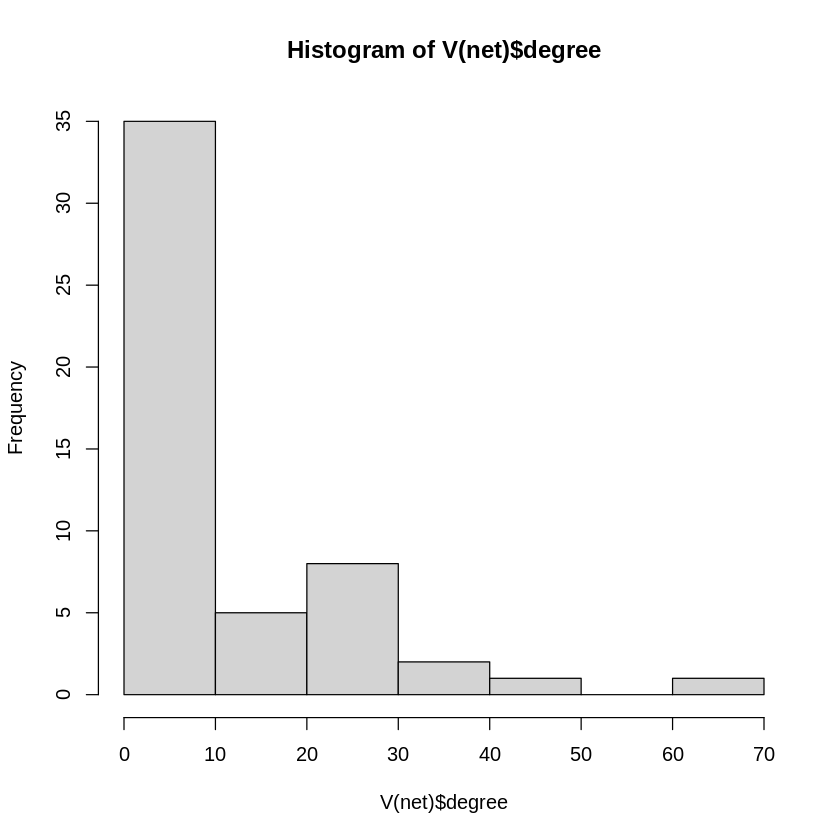

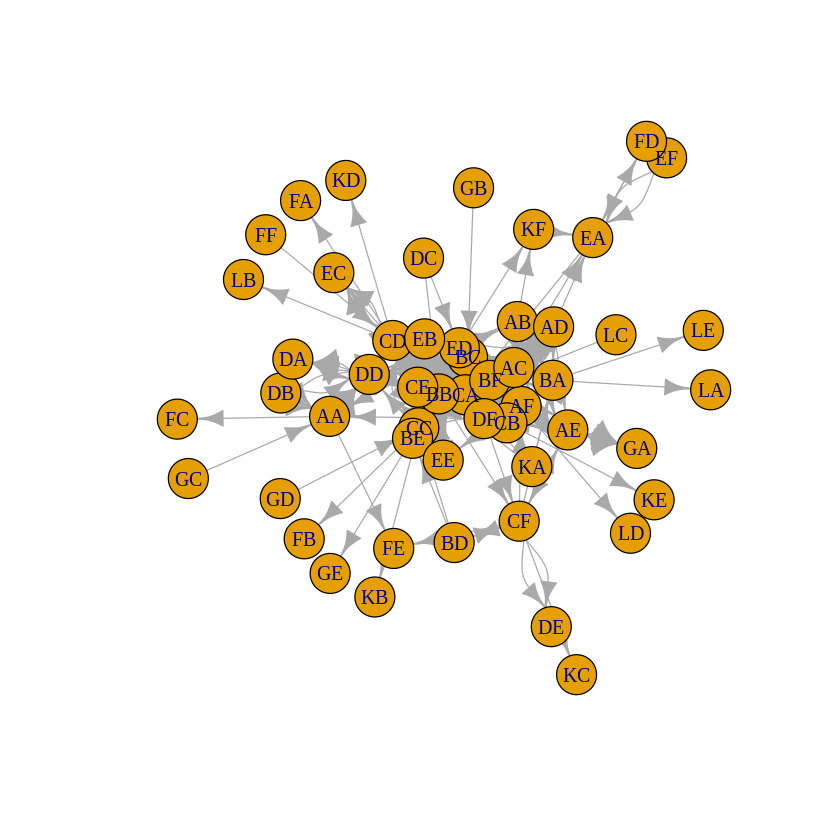

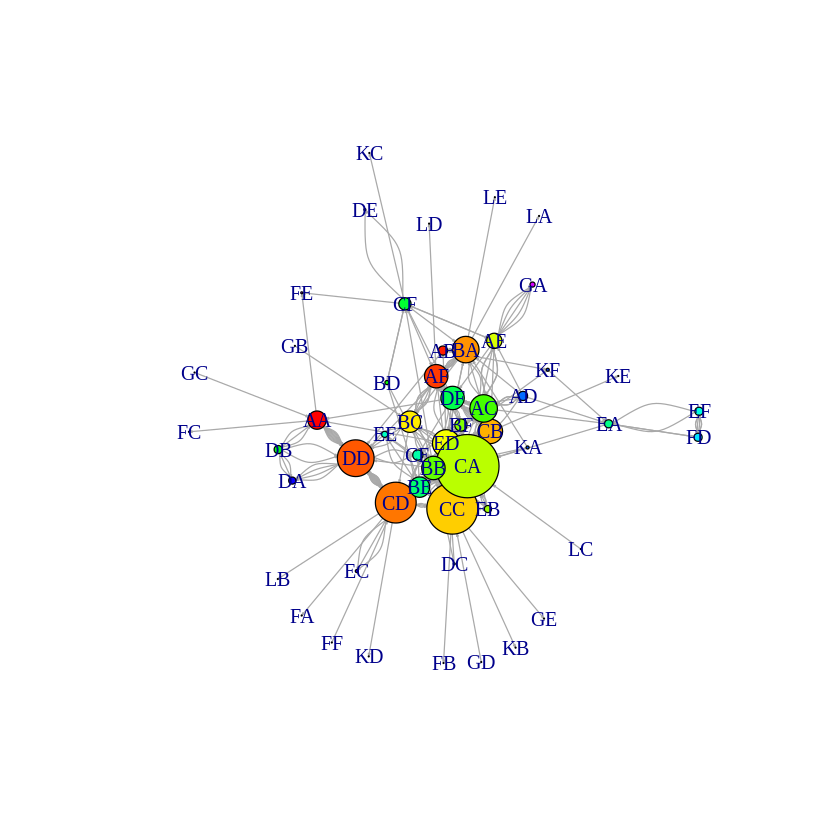

In [34]:
# Histogram of node degree
hist(V(net)$degree)

# Network diagram
plot(net)

# Highlighting degrees & layouts
plot(net,
     vertex.color = rainbow(52),
     vertex.size = V(net)$degree*0.4,
     edge.arrow.size = 0.1,
     layout=layout.fruchterman.reingold)

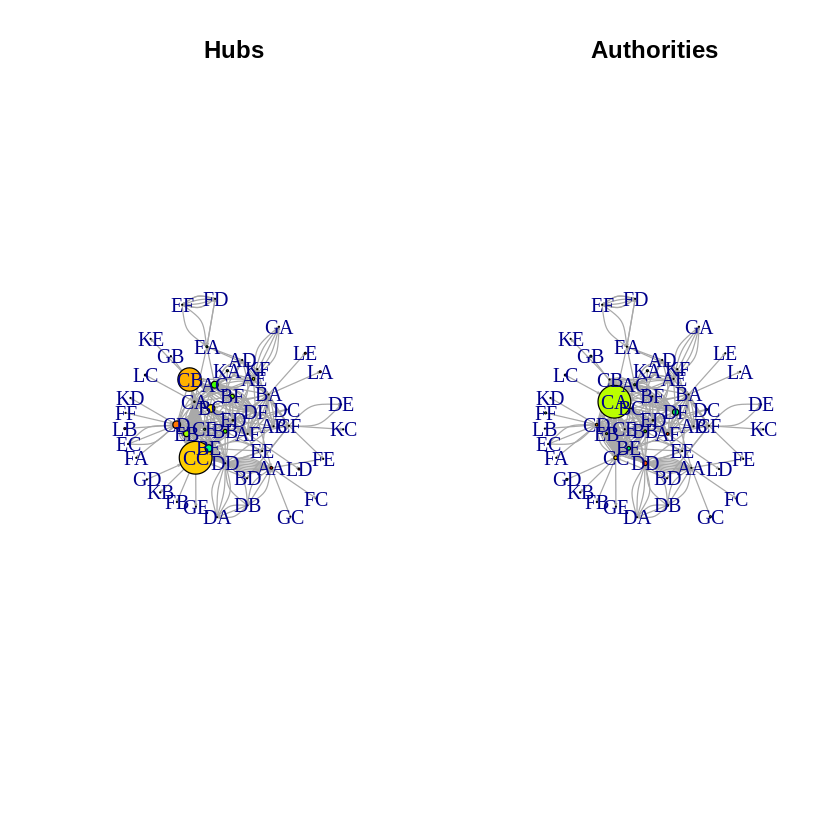

In [35]:
# Hub and authorities
hs <- hub_score(net)$vector
as <- authority.score(net)$vector
par(mfrow=c(1,2))
set.seed(123)
plot(net,
     vertex.size=hs*30,
     main = 'Hubs',
     vertex.color = rainbow(52),
     edge.arrow.size=0.1,
     layout = layout.kamada.kawai)

plot(net,
     vertex.size=as*30,
     main = 'Authorities',
     vertex.color = rainbow(52),
     edge.arrow.size=0.1,
     layout = layout.kamada.kawai)
par(mfrow=c(1,1))

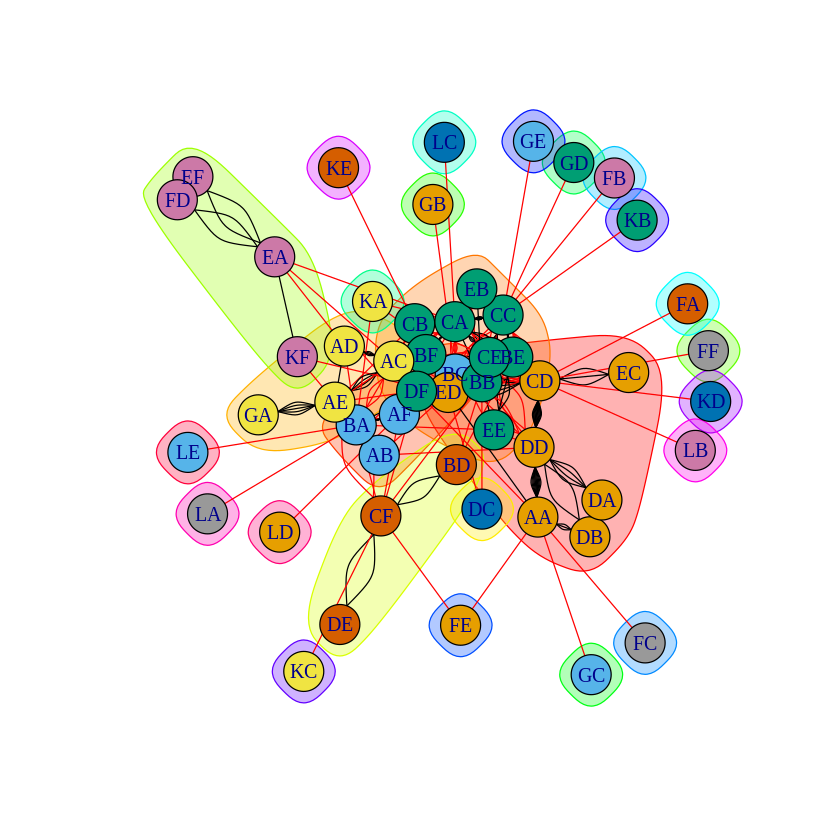

In [31]:
# Community detection using updated functions
net_undirected <- graph_from_data_frame(y, directed = FALSE)
cnet <- cluster_edge_betweenness(net_undirected)
plot(cnet, net_undirected)